In [15]:
import yaml
import numpy as np
import polars as pl
import polars.selectors as cs
from tqdm import tqdm
import statsmodels.api as sm

from plotnine import *
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

In [16]:
# Configuration and paths
mac = 20

# ============================================================
# Variant class selection — change this to switch variant class
# Available: missense, missense_structured, missense_non_structured,
#   missense_disordered, missense_lip, intron,
#   enhancer_encode, promoter_encode, tf_encode, core_promoter
# ============================================================
variant_class = 'missense'

selected_categories = ['protein_domains']
# selected_categories = ['plof_consequences']
# selected_categories = ['clinvar']

only_snps = False  # Whether to include only SNPs (exclude indels)

only_clinvar = False
exclude_clinvar = False  # Independent toggle: exclude ClinVar-annotated variants
ci_factor = 1.96  # For 95% confidence intervals
abs_phenotypes = False  # Whether to take absolute value of phenotypes (for direction-agnostic analysis)

eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'

# Load variant class configuration
variant_class_path = "/home/dnanexus/ukbgym/config_variant_classes.yaml"
with open(variant_class_path) as f:
    variant_class_config = yaml.safe_load(f)

vc = variant_class_config[variant_class]
vc_filters = vc['variant_filtering']

print(f"Variant class: {variant_class}")
print(f"  Filters: {vc_filters}")
print(f"  Exclude ClinVar: {exclude_clinvar}")

# Load annotation configuration
config_path = "/home/dnanexus/ukbgym/config_pheno.yaml" 

with open(config_path) as f:
    config = yaml.safe_load(f)
    
records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records).with_columns(
    pl.col("annotation_dir").cast(pl.Int8)
)

all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()

anno_config_df

Variant class: missense
  Filters: ["pl.col('consequence_missense_variant') == True"]
  Exclude ClinVar: False


category,annotation,color,label,annotation_dir
str,str,str,str,i8
"""plof""","""loftee_hc""","""#E31A1C""","""LOFTEE HC""",1
"""plof_consequences""","""consequence_frameshift_variant""","""#E31A1C""","""VEP Frameshift""",1
"""plof_consequences""","""consequence_stop_gained""","""#FB9A99""","""VEP Stop Gained""",1
"""plof_consequences""","""consequence_splice_donor_varia…","""#6A1B9A""","""VEP Splice Donor""",1
"""plof_consequences""","""consequence_splice_acceptor_va…","""#AB47BC""","""VEP Splice Acceptor""",1
…,…,…,…,…
"""vep_consequences""","""consequence_stop_lost""","""#FFB300""","""VEP Stop Lost""",1
"""vep_consequences""","""consequence_missense_variant""","""#1E90FF""","""VEP Missense""",1
"""vep_consequences""","""consequence_synonymous_variant""","""#C6DBEF""","""VEP Synonymous""",1


In [17]:
# Subset Olink RVAT significant
LOCAL_DATA_DIR = "/home/dnanexus/data_dir/"

# olink_burden_test_file = "proteomics_prs_am_loftee_mac20_burden_regression_results.parquet"
# olink_burden_test_file = "proteomics_prs_loftee_mac20_burden_regression_results.parquet"
olink_burden_test_file = "proteomics_prs_df_loftee_mac20_burden_regression_results.parquet"
!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/olink/blacklist/{olink_burden_test_file} -o {LOCAL_DATA_DIR}/{olink_burden_test_file}

olink_whitelist = (
    pl.read_parquet(f'{LOCAL_DATA_DIR}/{olink_burden_test_file}')
    .rename({'gene': 'region'})
    .filter((pl.col('padj')<=0.05) & (pl.col('wilcox_padj')<=0.05) )
    .select(['region'])
    .with_columns(
        phenotype = pl.col('region') + '_olink'
    )
)

# olink_correlations_file = "olink_all_mac20_lofteeHC_correlations.parquet"
olink_correlations_file = "olink_LOFTEE_correlations_protrider_t_df_loftee_mac20_EURunrelated_appv_percentiles_small_desc.parquet"
!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/REGENIE_results/{olink_correlations_file} -o {LOCAL_DATA_DIR}/{olink_correlations_file}

olink_corrs = (
    pl.read_parquet(f'{LOCAL_DATA_DIR}/{olink_correlations_file}')
    .filter(pl.col('correlation')>0)
    .with_columns(
        loftee_corr = pl.col('correlation'),
        loftee_corr_abs = pl.col('correlation').abs(),
        loftee_corr_dir = pl.col('correlation')/pl.col('correlation').abs(),
    )
    .drop_nans()
    .select(['region', 'phenotype', 'loftee_corr', 'loftee_corr_abs', 'loftee_corr_dir']) 
)

olink_whitelist = (
    olink_whitelist
    .join(olink_corrs, on=['region', 'phenotype'], how='inner')
    .drop_nans()
    # .sort('loftee_corr_abs', descending=True)
    # .sort('pval_fdr')
    # .unique(subset=["region"], keep="first", maintain_order=True)
)

olink_whitelist

Error: path "/home/dnanexus/data_dir//proteomics_prs_df_loftee_mac20_burden_re
gression_results.parquet" already exists but -f/--overwrite was not set
Error: path "/home/dnanexus/data_dir//olink_LOFTEE_correlations_protrider_t_df
_loftee_mac20_EURunrelated_appv_percentiles_small_desc.parquet" already exists
but -f/--overwrite was not set


region,phenotype,loftee_corr,loftee_corr_abs,loftee_corr_dir
str,str,f64,f64,f64
"""ENSG00000116675""","""ENSG00000116675_olink""",0.022487,0.022487,1.0
"""ENSG00000123609""","""ENSG00000123609_olink""",0.076186,0.076186,1.0
"""ENSG00000167851""","""ENSG00000167851_olink""",0.066067,0.066067,1.0
"""ENSG00000156711""","""ENSG00000156711_olink""",0.04852,0.04852,1.0
"""ENSG00000174990""","""ENSG00000174990_olink""",0.010786,0.010786,1.0
…,…,…,…,…
"""ENSG00000136542""","""ENSG00000136542_olink""",0.040315,0.040315,1.0
"""ENSG00000196576""","""ENSG00000196576_olink""",0.082542,0.082542,1.0
"""ENSG00000111144""","""ENSG00000111144_olink""",0.088107,0.088107,1.0


In [18]:
RAP_ANNO_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/wgs/qced_maf1e-3_loftee_olink_genes/qced_maf1e-3_loftee_olink_genes_EURunrelated"
LOCAL_ANNO_DIR = "/home/dnanexus/data_dir"

# ANNO_FILE = "annotations_fillna_ukbgym_with_mane.parquet"
ANNO_FILE = "annotations_with_all_no_dup.parquet"

!dx download {RAP_ANNO_DIR}/{ANNO_FILE} -o {LOCAL_ANNO_DIR}/{ANNO_FILE}
anno = pl.scan_parquet(f"{LOCAL_ANNO_DIR}/{ANNO_FILE}")

# Build dynamic filters from variant_class.yaml
if vc_filters is not None:
    _dynamic_filters = [eval(f) for f in vc_filters]
else:
    _dynamic_filters = []

if exclude_clinvar:
    _dynamic_filters.append(pl.col('clinical_significance').is_null())
elif only_clinvar:
    _dynamic_filters.append(pl.col('clinical_significance').is_not_null())

if only_snps:
    _dynamic_filters.append((pl.col('ref').str.len_chars()==1) & (pl.col('alt').str.len_chars()==1))  
    
anno = (
    anno
    .filter(
        # Always-applied filters
        (pl.col('region').is_in(olink_whitelist['region'].unique())),

        # Dynamic filters from variant_class.yaml + exclude_clinvar
        *_dynamic_filters,
    )
    .with_columns(
        promoterai_under = pl.col('promoterai'),
        promoterai_abs = pl.col('promoterai').abs(),

        non_ted_domain = pl.col('ted_domain') == False,

        clinvar_patho = pl.col('clinical_significance').str.contains('(?i)Pathogenic').fill_null(False),
        clinvar_likely_patho = pl.col('clinical_significance').str.contains('(?i)Likely_pathogenic').fill_null(False),
        clinvar_benign = pl.col('clinical_significance').str.contains('(?i)Benign').fill_null(False),
        clinvar_likely_benign = pl.col('clinical_significance').str.contains('(?i)Likely_benign').fill_null(False),

        loftee_disorder = pl.all_horizontal((pl.col(c) == True) for c in ['loftee_hc', 'mobi_curated_disorder_priority']),
        loftee_lip = pl.all_horizontal((pl.col(c) == True) for c in ['loftee_hc', 'mobi_full_lip_priority']),
        loftee_ted = pl.all_horizontal((pl.col(c) == True) for c in ['loftee_hc', 'ted_domain']),
        loftee_low_complexity = pl.all_horizontal((pl.col(c) == True) for c in ['loftee_hc', 'low_complexity_domain']),
    )
)

selected_annos = anno_config_df.filter(
    pl.col('category').is_in(selected_categories)
)['annotation'].to_list()

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]
selected_annos = list(set(selected_annos).intersection(set(existing_annos)))
fillna_cols = [c+'_is_na' for c in selected_annos]

anno = (
    anno
    .select(
        set(['id', 'region']).union(set(selected_annos))
    )
    .collect(engine='streaming')
    # .drop_nulls()
)

anno

Error: path "/home/dnanexus/data_dir/annotations_with_all_no_dup.parquet"
already exists but -f/--overwrite was not set


/tmp/ipykernel_106460/1117495193.py:55: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
/tmp/ipykernel_106460/1117495193.py:64: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


mobi_full_disorder_priority,low_complexity_domain,ted_domain,mobi_full_lip_priority,id,non_ted_domain,region
bool,bool,bool,bool,str,bool,str
false,false,true,false,"""chr1:157802386:T:C""",false,"""ENSG00000163534"""
false,false,false,false,"""chr11:72229527:C:T""",true,"""ENSG00000165458"""
false,false,true,true,"""chr17:81845578:C:G""",false,"""ENSG00000185624"""
false,false,false,false,"""chr15:74414583:G:C""",true,"""ENSG00000138623"""
false,false,true,false,"""chr1:160841214:A:C""",false,"""ENSG00000122223"""
…,…,…,…,…,…,…
false,false,false,true,"""chr19:8953621:C:T""",true,"""ENSG00000181143"""
false,false,false,false,"""chr8:143580646:C:T""",true,"""ENSG00000104529"""
false,false,true,false,"""chr18:79433671:C:G""",false,"""ENSG00000131196"""


In [19]:
melted_anno = (
    anno.lazy()

    .unpivot(
        index=["id", "region"],
        on=selected_annos,
        variable_name="annotation",
        value_name="annotation_score"
    )

    .filter(pl.col('annotation_score')==1)

    .with_columns(
        pl.col("annotation_score").cast(pl.Float32),
        pl.col("region").cast(pl.Utf8),
    )

    # Merge with annotation configuration to get direction and filter
    .join(
        anno_config_df.select(["annotation", "category", "annotation_dir"]).lazy(),
        on="annotation",
        how="left"
    )
    .filter(pl.col('category').is_in(selected_categories))
    .unique()

    .with_columns(
        # Changed because we have binary annotations
        annotation_score_dircor = (
            pl.when(pl.col("annotation_dir")!=1)
            .then((pl.col('annotation_score')-1).abs())
            .otherwise(pl.col('annotation_score'))
        )
    )

    .collect(engine='streaming')
)

melted_anno

id,region,annotation,annotation_score,category,annotation_dir,annotation_score_dircor
str,str,str,f32,str,i8,f32
"""chr9:36223419:T:G""","""ENSG00000159921""","""ted_domain""",1.0,"""protein_domains""",1,1.0
"""chr17:48137261:G:A""","""ENSG00000141293""","""ted_domain""",1.0,"""protein_domains""",1,1.0
"""chr7:107924029:T:A""","""ENSG00000091136""","""ted_domain""",1.0,"""protein_domains""",1,1.0
"""chr16:55529889:G:C""","""ENSG00000087253""","""ted_domain""",1.0,"""protein_domains""",1,1.0
"""chr1:145730783:C:T""","""ENSG00000117281""","""ted_domain""",1.0,"""protein_domains""",1,1.0
…,…,…,…,…,…,…
"""chr19:39173864:C:G""","""ENSG00000130669""","""ted_domain""",1.0,"""protein_domains""",1,1.0
"""chr15:89806142:G:T""","""ENSG00000166825""","""ted_domain""",1.0,"""protein_domains""",1,1.0
"""chr11:61118472:C:T""","""ENSG00000110448""","""ted_domain""",1.0,"""protein_domains""",1,1.0


In [20]:
melted_anno['annotation'].value_counts(sort=True)

annotation,count
str,u64
"""non_ted_domain""",178103
"""ted_domain""",176025
"""mobi_full_lip_priority""",70304
"""low_complexity_domain""",11898
"""mobi_full_disorder_priority""",6923


In [21]:
RAP_APPV_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/avg_pheno_per_var"
LOCAL_APPV_DIR = "/home/dnanexus"

# APPV_FILE = "cauc_protrider_lite_prs_t_df_all_genes_EURunrelated_appv_percentiles.parquet"
APPV_FILE = "olink_protrider_t_df_loftee_mac20_EURunrelated_appv_percentiles_small_desc.parquet"

!dx download {RAP_APPV_DIR}/{APPV_FILE} -o {LOCAL_APPV_DIR}/{APPV_FILE}
olink_appv = pl.scan_parquet(f"{LOCAL_APPV_DIR}/{APPV_FILE}")

# Small APPV file has no 'region' column — region is added via id_region join in the computation cell
olink_appv = (
    olink_appv
    .filter(
        (pl.col('n_individuals') <= mac)
    )
    .with_columns(
        mean_pheno_value = pl.when(abs_phenotypes)
        .then(pl.col('mean_pheno_value').abs())
        .otherwise(pl.col('mean_pheno_value'))
    )
    .select(['id', 'phenotype', 'mean_pheno_value', 'n_individuals'])
)

Error: path "/home/dnanexus/olink_protrider_t_df_loftee_mac20_EURunrelated_app
v_percentiles_small_desc.parquet" already exists but -f/--overwrite was not
set


In [22]:
all_pheno_df = (
    # A. Use a semi join for efficient filtering (more memory-safe than 'is_in')
    olink_appv
    # B. Join the other two dataframes
    .join(
        melted_anno.lazy(),
        on="id", 
        how="inner"
    )
    .join(
        olink_whitelist.lazy(), 
        on=["region", "phenotype"], 
        how="inner"
    )
    .with_columns(
        mean_pheno_value_dircor = pl.col('mean_pheno_value')# *pl.col('loftee_corr_dir')
    )
    .group_by(["annotation", "region", "phenotype"])
    .agg(
        n_vars = pl.col('id').n_unique(),
        mean_pheno_assoc = pl.col('mean_pheno_value_dircor').mean(),
    )
)

avg_pheno_df = (
    all_pheno_df.lazy()
    .group_by(["annotation"])
    .agg(
        n_gene_trait_assoc = pl.col('region').n_unique(),
        mean_pheno = pl.col('mean_pheno_assoc').mean(),
        se_pheno = pl.col('mean_pheno_assoc').std() / pl.col('region').n_unique().sqrt(),
        # ci_low_pheno = pl.col('mean_pheno_assoc').quantile(0.025),
        # ci_high_pheno = pl.col('mean_pheno_assoc').quantile(0.975),
    )
    .with_columns(
        ci_low_pheno = pl.col('mean_pheno') - ci_factor*pl.col('se_pheno'),
        ci_high_pheno = pl.col('mean_pheno') + ci_factor*pl.col('se_pheno'),
    )

    .collect(engine='streaming')
)

avg_pheno_df

annotation,n_gene_trait_assoc,mean_pheno,se_pheno,ci_low_pheno,ci_high_pheno
str,u64,f32,f64,f64,f64
"""mobi_full_lip_priority""",947,-0.423689,0.024978,-0.472646,-0.374733
"""ted_domain""",1019,-0.787968,0.020216,-0.827591,-0.748345
"""low_complexity_domain""",434,-0.261565,0.040472,-0.34089,-0.18224
"""non_ted_domain""",1049,-0.386244,0.018953,-0.423392,-0.349096
"""mobi_full_disorder_priority""",124,-0.405807,0.065148,-0.533498,-0.278117


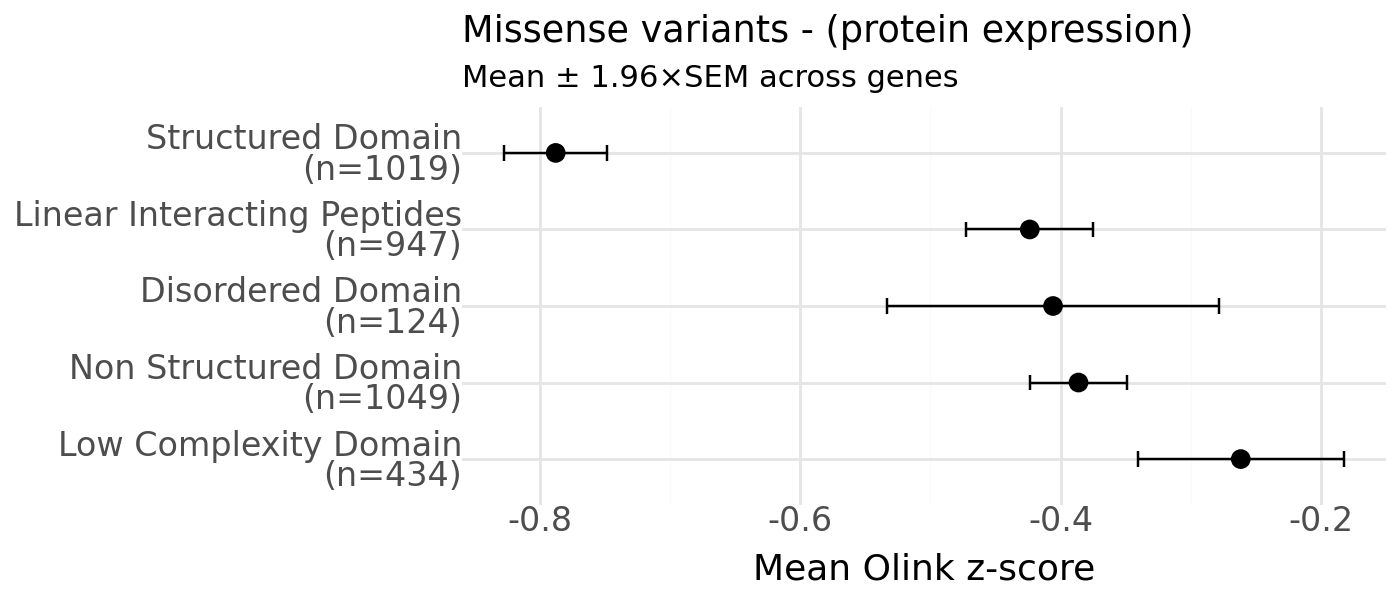

In [23]:
plof_pheno_df = (
    avg_pheno_df
    .join(
        anno_config_df.drop('category').unique(), 
        on='annotation'
    )
    .with_columns(
        # n_label = pl.col('label') + "\n(n=" + pl.col('n_vars').cast(pl.Utf8) + ")"
        n_label = pl.col('label') + "\n(n=" + pl.col('n_gene_trait_assoc').cast(pl.Utf8) + ")"
    )
    .drop_nans()
)

# 2. Determine the categorical order for the labels
ordered_labels = (
    plof_pheno_df
    .sort("mean_pheno", descending=True)
    .select("n_label")
    .unique(maintain_order=True)
    .to_series()
)

# 3. Apply the ordering using pl.Enum
plof_pheno_df = plof_pheno_df.with_columns(pl.col("n_label").cast(pl.Enum(ordered_labels)))

# 4. Create the color dictionary (Polars style)
color_dict = dict(plof_pheno_df.select("annotation", "color").unique().iter_rows())

if exclude_clinvar:
    plot_title = f"{vc['x_label']} (no ClinVar)"
elif only_clinvar:
    plot_title = f"{vc['x_label']} (only ClinVar)"
else:
    plot_title = vc['x_label']

if only_snps:
    plot_title += " (SNPs)"

# Plot
(
    ggplot(
        plof_pheno_df,
        aes(x='n_label', y='mean_pheno')
    )
    # + geom_hline(yintercept=0, linetype='dashed', color='grey')
    + geom_point(size=3)
    + geom_errorbar(
        aes(ymin='ci_low_pheno', ymax='ci_high_pheno'),
        width=0.2,
    )
    + labs(
        title=f"{plot_title} variants - (protein expression)",
        subtitle=f"Mean ± {ci_factor}×SEM across genes",
        x='', 
        y='Mean Olink z-score'
    )
    + coord_flip()
    + theme_minimal()
    + theme(
        figure_size=(7, plof_pheno_df['annotation'].n_unique()/2 + 0.5),
        axis_text=element_text(size=12),
        axis_title=element_text(size=13),
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
        plot_background=element_rect(fill="white", color="white"),
    )
)

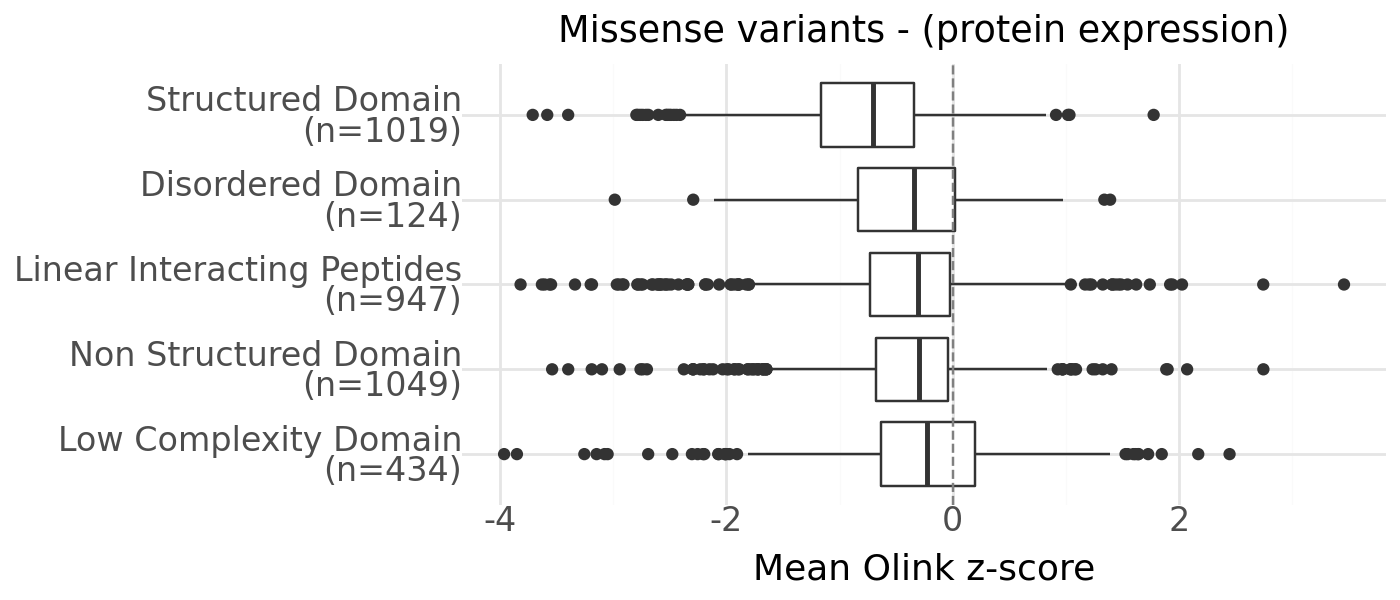

In [24]:
# Calculate medians and join back
box_pheno_df = (
    all_pheno_df.collect()
    .join(
        anno_config_df.drop('category').unique(), 
        on='annotation'
    )
    .join(
        avg_pheno_df.select('annotation', 'n_gene_trait_assoc').unique(),
        on='annotation'
    )
    .with_columns(
        # n_label = pl.col('label') + "\n(n=" + pl.col('n_vars').cast(pl.Utf8) + ")"
        n_label = pl.col('label') + "\n(n=" + pl.col('n_gene_trait_assoc').cast(pl.Utf8) + ")"
    )
    .drop_nans()
    .with_columns(
        median_mean_pheno = pl.col('mean_pheno_assoc').median().over("annotation")
    )
)

# 2. Determine the categorical order for the labels
ordered_labels = (
    box_pheno_df
    .sort("median_mean_pheno", descending=True)
    .select("n_label")
    .unique(maintain_order=True)
    .to_series()
)

# 3. Apply the ordering using pl.Enum
box_pheno_df = box_pheno_df.with_columns(pl.col("n_label").cast(pl.Enum(ordered_labels)))

# 4. Create the color dictionary (Polars style)
color_dict = dict(box_pheno_df.select("annotation", "color").unique().iter_rows())

if exclude_clinvar:
    plot_title = f"{vc['x_label']} (no ClinVar)"
elif only_clinvar:
    plot_title = f"{vc['x_label']} (only ClinVar)"
else:
    plot_title = vc['x_label']

if only_snps:
    plot_title += " (SNPs)"

# Plot
(
    ggplot(
        box_pheno_df,
        aes(x='n_label', y='mean_pheno_assoc')
    )
    + geom_boxplot(width=0.75)
    + geom_hline(yintercept=0, linetype='dashed', color='grey')
    + labs(
        title=f"{plot_title} variants - (protein expression)",
        x='', 
        y='Mean Olink z-score'
    )
    + coord_flip()
    + theme_minimal()
    + theme(
        figure_size=(7, box_pheno_df['annotation'].n_unique()/2 + 0.5),
        axis_text=element_text(size=12),
        axis_title=element_text(size=13),
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
        plot_background=element_rect(fill="white", color="white"),
    )
)